# India Air Quality Analysis: Data Quality & Understanding

## Project Objective

Air pollution is one of India's most pressing environmental challenges. This project analyzes air quality measurements collected from multiple Indian cities to understand pollution patterns, assess data quality, and prepare the dataset for downstream analytics.

This notebook focuses on:

* Understanding dataset structure
* Assessing data quality
* Identifying missing values
* Exploring AQI distributions
* Understanding temporal pollution patterns
* Evaluating seasonal variations

The cleaned dataset produced in this notebook will be used for SQL analysis and Power BI dashboard development.


## Import Required Libraries

The analysis begins by importing Python libraries used for data manipulation, visualization, and exploratory analysis.

* Pandas: Data manipulation and analysis
* NumPy: Numerical operations
* Matplotlib: Basic visualization
* Seaborn: Statistical visualizations


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display all columns
pd.set_option('display.max_columns', None)

print("Libraries Imported Successfully")


Libraries Imported Successfully


##  Load Dataset

The dataset is loaded into a Pandas DataFrame.

At this stage, the objective is simply to verify that the file is accessible and correctly imported before performing any analysis.

In [3]:
df = pd.read_csv("cleaned_aqi.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


## Dataset Dimensions

Understanding the size of the dataset is an important first step.

This helps estimate:

- Number of observations available
- Number of features collected
- Overall scale of analysis

In [4]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 24307
Columns : 18


## Step 4: Feature Overview

The dataset contains air quality measurements, pollutant concentrations, temporal variables, and AQI classifications.

Reviewing available columns helps identify variables that may be useful for future analysis.

In [7]:
df.columns.tolist()

['City',
 'Date',
 'PM2.5',
 'PM10',
 'NO',
 'NO2',
 'NOx',
 'NH3',
 'CO',
 'SO2',
 'O3',
 'Benzene',
 'Toluene',
 'AQI',
 'AQI_Bucket',
 'Year',
 'Month',
 'Week']

In [8]:
# ==========================================
# FIRST 5 RECORDS
# ==========================================

df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,AQI,AQI_Bucket,Year,Month,Week
0,Ahmedabad,29-01-2015,83.13,95.64,6.93,28.71,33.72,16.27,6.93,49.52,59.76,0.02,0.0,209,Poor,2015,1,5
1,Ahmedabad,30-01-2015,79.84,95.64,13.85,28.68,41.08,16.27,13.85,48.49,97.07,0.04,0.0,328,Very Poor,2015,1,5
2,Ahmedabad,04-02-2015,80.65,95.64,2.37,22.83,24.00,16.27,2.37,25.73,47.30,0.00,0.0,294,Poor,2015,2,6
3,Ahmedabad,05-02-2015,58.36,95.64,2.60,21.39,23.31,16.27,2.60,32.66,53.54,0.00,0.0,149,Moderate,2015,2,6
4,Ahmedabad,06-02-2015,79.29,95.64,1.16,26.94,26.83,16.27,1.16,67.41,59.30,0.00,0.0,190,Moderate,2015,2,6


## Step 6: Descriptive Statistics

Descriptive statistics provide an overview of the numerical characteristics of the dataset, including:

- Mean
- Median
- Standard deviation
- Minimum values
- Maximum values

These metrics help identify unusual distributions and potential outliers.

In [14]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PM2.5,24307.0,64.922884,57.286103,0.04,29.185,48.045,77.660,868.66
PM10,24307.0,110.900722,73.416927,0.03,70.525,95.640,123.185,847.41
NO,24307.0,16.838667,21.470627,0.03,5.640,9.710,18.710,390.68
NO2,24307.0,27.677843,22.140963,0.01,11.900,21.670,36.830,362.21
NOx,24307.0,30.649074,28.515569,0.00,13.800,23.170,36.910,378.24
NH3,24307.0,21.879250,22.575016,0.01,11.100,16.270,25.045,352.89
CO,24307.0,1.637772,3.610813,0.00,0.580,0.920,1.410,175.81
SO2,24307.0,13.223079,14.814744,0.01,5.740,9.060,14.420,186.08
O3,24307.0,34.586000,21.206519,0.01,19.535,30.960,45.090,200.41
Benzene,24307.0,3.037687,14.947541,0.00,0.320,1.250,2.740,455.03


In [15]:
# AQI Summary

df['AQI'].describe()

count    24307.000000
mean       153.345909
std        102.323170
min         13.000000
25%         80.000000
50%        116.000000
75%        197.000000
max        500.000000
Name: AQI, dtype: float64

## Step 7: AQI Distribution Analysis

AQI is the primary indicator of air quality.

Understanding its distribution helps answer:

- Are pollution levels generally low or high?
- Are severe pollution events common?
- Is the distribution skewed?

The histogram below visualizes the overall AQI distribution.

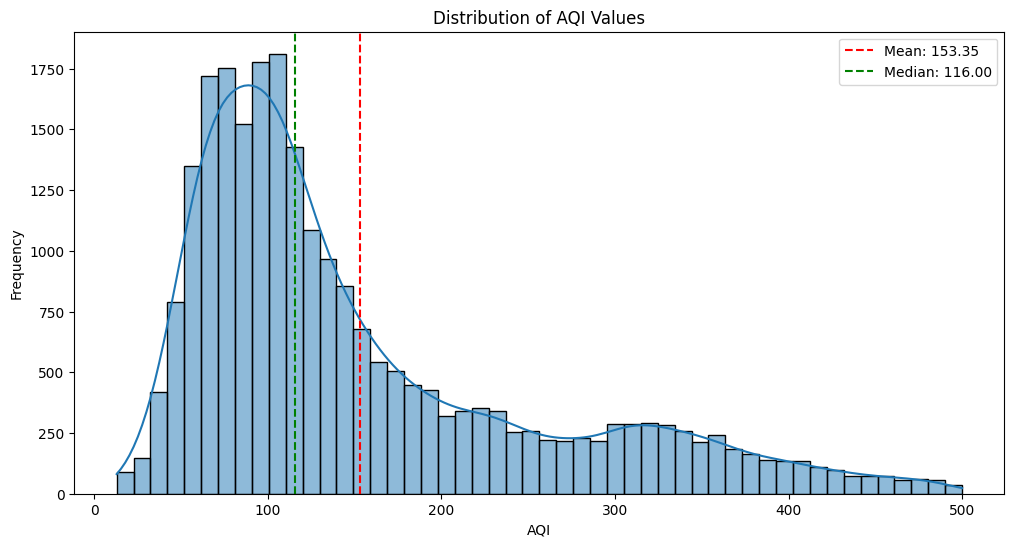

In [17]:
plt.figure(figsize=(12,6))

sns.histplot(
    df['AQI'],
    bins=50,
    kde=True
)

plt.axvline(
    df['AQI'].mean(),
    color='red',
    linestyle='--',
    label=f"Mean: {df['AQI'].mean():.2f}"
)

plt.axvline(
    df['AQI'].median(),
    color='green',
    linestyle='--',
    label=f"Median: {df['AQI'].median():.2f}"
)

plt.title("Distribution of AQI Values")

plt.xlabel("AQI")

plt.ylabel("Frequency")

plt.legend()

plt.show()

### Observation

The AQI distribution is positively skewed, indicating that while moderate pollution levels are common, extreme pollution events also occur.

The difference between the mean and median suggests the presence of high-pollution outliers.

## Step 8: AQI Category Distribution

AQI categories provide a more interpretable view of air quality than raw AQI values.

This analysis evaluates the proportion of observations falling into each pollution category.

In [18]:
df['AQI_Bucket'].value_counts()

AQI_Bucket
Moderate        8829
Satisfactory    8224
Poor            2781
Very Poor       2337
Good            1341
Severe           795
Name: count, dtype: int64

In [19]:
# ==========================================
# AQI CATEGORY PERCENTAGE
# ==========================================

aqi_bucket_pct = round(
    df['AQI_Bucket']
      .value_counts(normalize=True)
      .mul(100),
    2
)

aqi_bucket_pct

AQI_Bucket
Moderate        36.32
Satisfactory    33.83
Poor            11.44
Very Poor        9.61
Good             5.52
Severe           3.27
Name: proportion, dtype: float64

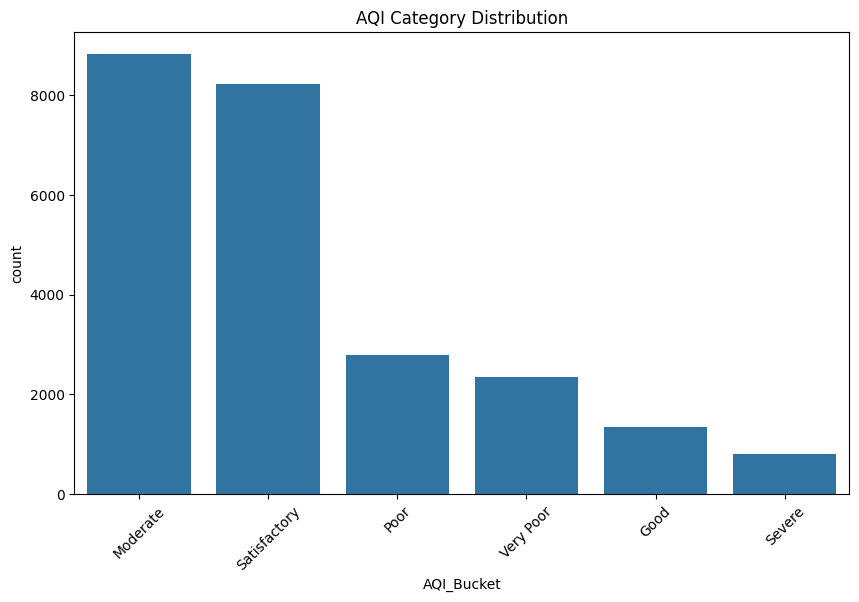

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x='AQI_Bucket',
    order=df['AQI_Bucket'].value_counts().index
)

plt.title("AQI Category Distribution")

plt.xticks(rotation=45)

plt.show()

### Observation

The distribution reveals that a substantial proportion of observations fall within the Moderate and Satisfactory categories, while Severe pollution episodes occur less frequently.

However, even a small percentage of Severe observations represents a significant public health concern.

## Step 9: Annual AQI Trend Analysis

Long-term AQI trends help determine whether air quality is improving or deteriorating over time.

Average AQI is calculated for each year and visualized below.

In [ ]:
yearly_aqi = (
    df.groupby('Year')['AQI']
      .mean()
      .reset_index()
)

yearly_aqi

,Year,AQI
0,2015,199.385915
1,2016,187.785374
2,2017,171.017323
3,2018,159.217675
4,2019,143.205495
5,2020,110.934378


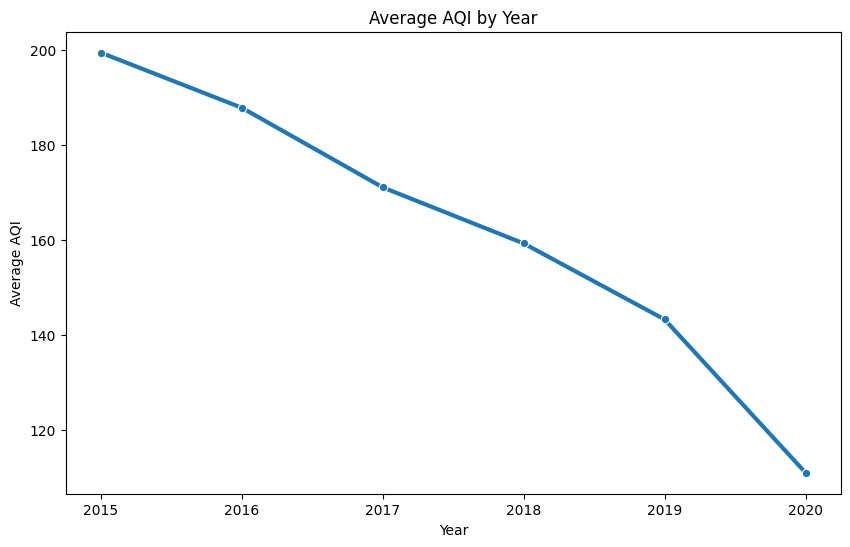

In [ ]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=yearly_aqi,
    x='Year',
    y='AQI',
    marker='o',
    linewidth=3
)

plt.title("Average AQI by Year")

plt.ylabel("Average AQI")

plt.show()


In [ ]:
yearly_aqi['YoY_%'] = (
    yearly_aqi['AQI']
    .pct_change() * 100
)

yearly_aqi

,Year,AQI,YoY_%
0,2015,199.385915,NaN
1,2016,187.785374,-5.818135
2,2017,171.017323,-8.929370
3,2018,159.217675,-6.899680
4,2019,143.205495,-10.056785
5,2020,110.934378,-22.534832


### Key Insight

The trend indicates a gradual decline in average AQI over the study period, suggesting an overall improvement in air quality.

## Step 10: Monthly AQI Trend Analysis

Air pollution often exhibits seasonal behavior due to:

- Weather conditions
- Temperature inversions
- Agricultural residue burning
- Festival emissions

Monthly averages are analyzed to identify recurring patterns.

In [ ]:
monthly_aqi = (
    df.groupby('Month')['AQI']
      .mean()
      .reset_index()
)

monthly_aqi

,Month,AQI
0,1,213.392460
1,2,183.076238
2,3,148.599208
3,4,134.193634
4,5,132.391358
5,6,115.302155
6,7,105.053532
7,8,106.459475
8,9,108.634006
9,10,167.040592


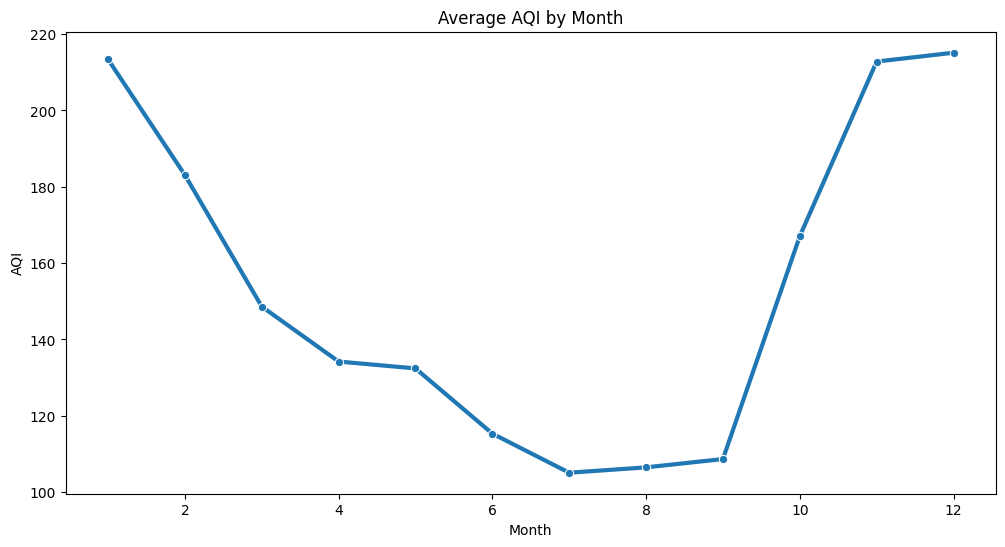

In [ ]:
plt.figure(figsize=(12,6))

sns.lineplot(
    data=monthly_aqi,
    x='Month',
    y='AQI',
    marker='o',
    linewidth=3
)

plt.title("Average AQI by Month")

plt.show()

## Step 11: Seasonal Pollution Analysis

To better understand seasonal effects, months are grouped into four seasons:

- Winter
- Summer
- Monsoon
- Post-Monsoon

Average AQI is then compared across seasons.

In [ ]:
def get_season(month):

    if month in [12,1,2]:
        return 'Winter'

    elif month in [3,4,5]:
        return 'Summer'

    elif month in [6,7,8,9]:
        return 'Monsoon'

    else:
        return 'Post-Monsoon'

df['Season'] = df['Month'].apply(get_season)

In [ ]:
seasonal_aqi = (
    df.groupby('Season')['AQI']
      .mean()
      .sort_values(ascending=False)
)

seasonal_aqi

Season
Winter          203.861950
Post-Monsoon    190.023497
Summer          138.266045
Monsoon         109.312902
Name: AQI, dtype: float64

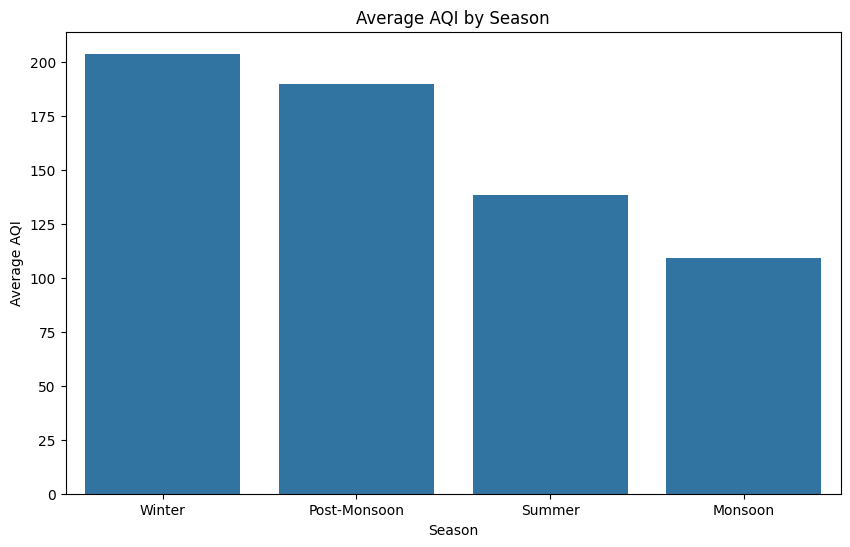

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(
    x=seasonal_aqi.index,
    y=seasonal_aqi.values
)

plt.title("Average AQI by Season")

plt.ylabel("Average AQI")

plt.show()

### Key Insight

Winter months exhibit the highest AQI levels, indicating poorer air quality.

This may be attributed to lower atmospheric dispersion, temperature inversions, and increased pollutant accumulation.

## Step 12: City Coverage Analysis

The dataset includes observations from multiple Indian cities.

Evaluating city-level observation counts helps assess the representativeness of the dataset and identify locations with greater monitoring coverage.

In [ ]:
df['City'].nunique()

26

In [ ]:
city_count = (
    df['City']
      .value_counts()
      .head(15)
)

city_count

City
Delhi                 1951
Bengaluru             1910
Chennai               1884
Lucknow               1878
Hyderabad             1876
Patna                 1434
Gurugram              1431
Visakhapatnam         1171
Amritsar              1122
Jaipur                1094
Thiruvananthapuram    1052
Ahmedabad              922
Amaravati              841
Mumbai                 775
Jorapokhar             764
Name: count, dtype: int64

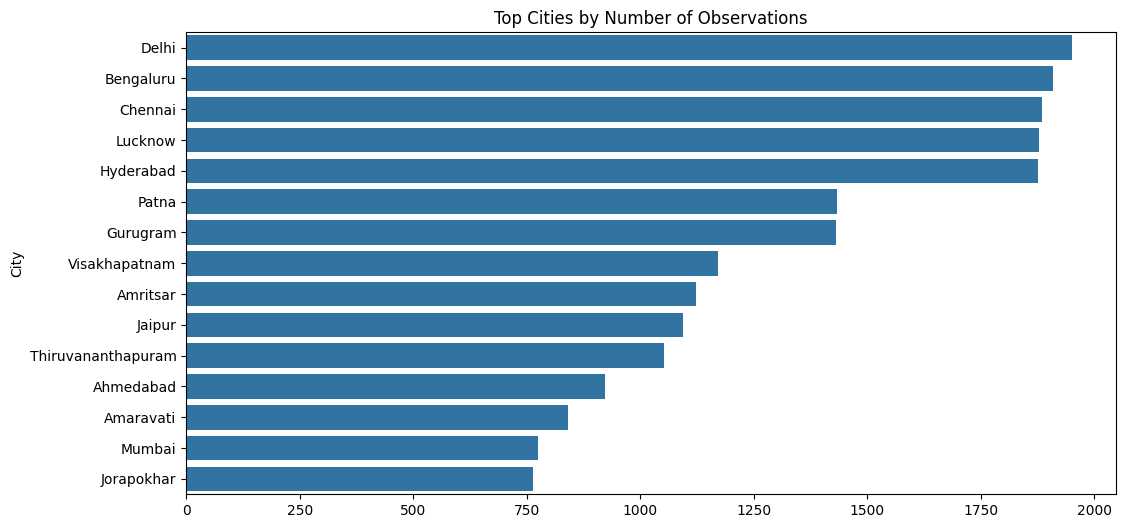

In [ ]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=city_count.values,
    y=city_count.index
)

plt.title("Top Cities by Number of Observations")

plt.show()

# Notebook Summary

Key findings from this data quality and understanding phase include:

* The dataset contains air quality observations from multiple Indian cities.
* Missing values were identified and assessed to understand data quality issues.
* The Xylene feature was removed due to excessive missingness.
* AQI values exhibit a positively skewed distribution, indicating occasional severe pollution events.
* Seasonal analysis revealed higher pollution levels during winter months.
* Annual AQI trends suggest changes in air quality over time that warrant further investigation.

The cleaned and validated dataset generated in this notebook will serve as the foundation for advanced exploratory analysis, SQL-based querying, and Power BI dashboard development.
